<h1>ML basics</h1>
Deep learning works by performing large‑scale numerical computation on tensor (scalars, vectors, matrices and higher‑dimensional arrays). Getting comfortable with shape, rank, dtype and a few core operations (indexing, broadcasting, matmul, reductions) prevents most bugs when building models.

Import TensorFlow (GPU/CPU numerical engine + deep learning library) and NumPy (general numerical Python library). Print the TF version. Some behaviors (e.g., default dtypes) can vary across versions.

In [1]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)

TF: 2.20.0


Rank = number of axes (dimensions).  
scalar has rank 0 (shape=()) > a single number;  
vector rank 1 (shape=(3,));  
matrix rank 2 (shape=(2,2));  
tensor rank 3 (shape=(2,2,1)).  
Shape = size along each axis (batch, height, width...).

  
Your models understand only numbers and shapes. 

In [2]:
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7)  # rank-0
vector = tf.constant([10, 20, 30]) # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2
tensor  = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1)

print(scalar.shape, vector.shape, matrix.shape, tensor.shape)

() (3,) (2, 2) (2, 2, 1)


<i>Extra task:</i><br>
What’s the rank/shape of an RGB image with 32 images 64×64 pixels?

In [3]:
img_batch = tf.zeros([32, 64, 64, 3])  # 32 images, 64×64, RGB
print(img_batch.shape, img_batch.ndim) # (32, 64, 64, 3), rank=4

(32, 64, 64, 3) 4


tf.zeros([32, 64, 64, 3]) creates a new tensor of the given shape filled with zeros. In the context of images 0 means no intensity > a completely black pixel.<br><br>
So img_batch is a batch of 32 solid‑black images, each 64×64 with 3 color channels.

In [4]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats
y32 = tf.cast(y, tf.float32) # cast ints → floats

A dtype (data type) tells TensorFlow what kind of numbers a tensor stores, e.g., float32, float16, int32, or bool. It’s one of the three core properties of a tensor alongside shape and rank. The dtype you choose affects memory use and numerical precision, so it has practical consequences for speed and stability.
<br><br>
Casting changes dtype without changing shape. float16 halves memory but reduces precision. Good for speed on certain GPUs.

In [5]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)

: picks all rows. 
-1 selects the last column. last_col has shape (2,).

<b>Reshaping:</b>

expand_dims(..., -1) adds a new axis at the end: (2,2) > (2,2,1).<br>
squeeze(..., axis=-1) removes a size‑1 axis: back to (2,2).

In [6]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Basic ops: +, * operate per position. This is different from matrix multiplication (tf.matmul).

Matmul rule: For A @ B, the inner dimensions must match: (m×n) @ (n×p) -> (m×p). So you transpose Y (from (3×2) to (2×3)) to make 2 match 2.<br><br>
Matrix multiplication is central to neural networks. 

In [7]:
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3)

In [8]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(),
      "sum:", tf.reduce_sum(E).numpy())


min: 2 max: 95 mean: 41.7 sum: 417


<b>Extra example  of why should we change int to float:</b>

In [9]:

M = tf.constant([[1., 2.], [3., 4.]])  # (2,2)
print(tf.reduce_mean(M, axis=0).numpy())  # column means -> [2., 3.]
print(tf.reduce_mean(M, axis=1).numpy())  # row means    -> [1.5, 3.5]

[2. 3.]
[1.5 3.5]


In [10]:
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh  = tf.one_hot(idx, depth=4)

Each integer label becomes a vector of length depth; only the index position is 1, others 0. Example:<br>
0 -> [1,0,0,0]<br>
1 -> [0,1,0,0]

In [11]:
labels = tf.constant([2, 0, 1])
print(tf.one_hot(labels, depth=3).numpy())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


You can convert NumPy arrays <-> TensorFlow tensors easily.

In [12]:

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t   = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy

print("OK")

OK


<h2>Regression model</h2><br>
The standard Keras workflow: Create -> Compile -> Fit -> Evaluate -> Predict -> Visualize.<br><br>
Separate train/test to measure generalization instead of memorization.

We use Matplotlib for visualization. 

In [13]:
#import tensorflow as tf
#import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20., -18., ..., 20.]
y = X + 10

<img src="Screenshot_function.png" alt="y=X + 10">

Split material, first 20 points for training, remaining for testing.<br><br>
Split to evaluate on data not seen during training to estimate generalization (how well the learned rule applies to new inputs).

In [15]:
# Train/test split (simple)
X_train, y_train = X[:20], y[:20]
X_test,  y_test  = X[20:], y[20:]

Read more: <a href="https://keras.io/guides/sequential_model/">Sequential model</a><br><br>
A Sequential model is Keras’s model type for a single straight pipeline: one input > layers in order > one output. It’s ideal whenever your architecture is a plain stack (no branches/merges). This includes simple regression or classification on a single input vector and single input image pipelines. 

If the task has multiple inputs (e.g., image + numeric features) or needs branching/merging, switch to the Functional API. With Functional, you can build separate layer branches, an MLP (Dense) branch for numeric features and a CNN (Conv2D/MaxPool2D) branch for images. Then merge their features (e.g., Concatenate) and finish with a linear Dense output for regression (e.g. house price depending on size + photo).

A layer takes one or more tensors in and outputs one or more tensors after applying a computation (its call method). It also holds state (weights) that training updates. Layers are the basic building blocks you stack to form models. 

API in this case means a set of classes and methods you call to build neural networks.

In [16]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)  # linear output for regression
])

A loss function turns your model’s mistakes into one number so the training loop knows how “wrong” the model is right now. Keras needs this number to decide how to adjust the weights on the next step. Without a loss, the model has no target to improve.
Why we need it (practically):

Gives the optimizer a target. During model.fit, Keras computes the loss on each batch and the optimizer uses it to nudge the weights to make that number smaller next time.

Enables training with one line. model.compile(loss=..., optimizer=..., metrics=...) wires everything so Keras can run the built‑in training loop. 
Lets you compare and monitor. You can watch training vs. validation loss to see if you’re improving, plateauing, or overfitting.

In [17]:
# 2) COMPILE
model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["mae"]
)

model.fit(...) runs Keras’s built‑in training loop. On each epoch, the model makes predictions on batches of X_train, computes the loss against y_train, and the optimizer updates the weights to try to reduce that loss next time. The call returns a History object that contains per‑epoch logs (e.g., loss) in history.history.
epochs=200: “Try the whole dataset 200 times.” More epochs can help if the model hasn’t converged yet—but watch validation to avoid overfitting. 
<br><br>
verbose=0: hides per‑epoch printing. Use verbose=1 to show an epoch‑by‑epoch progress line, or verbose=2 to show one summary line per epoch.
<br><br>
If you want training to stop automatically when improvement stalls, add callbacks like EarlyStopping (optionally restoring the best weights). This is standard practice in Keras. 

In [18]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=200, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - loss: 15.0181 - mae: 15.0181
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 14.2428 - mae: 14.2428
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 13.5151 - mae: 13.5151
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 12.8735 - mae: 12.8735
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 12.2319 - mae: 12.2319
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 11.6388 - mae: 11.6388
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.1463 - mae: 11.1463
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 10.6794 - mae: 10.6794
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 10.3394 - mae: 10.3394
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 10.0242 - mae: 10.0242
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 9.8257 - mae: 9.8257
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.6527 - mae: 9.6527
Epoch 13/200
1/1 ━━━━━━━━━━━

model.evaluate(...) runs the model on unseen test data and computes the loss and any metrics you set in compile. This measures generalization, not training progress.
<br><br> 
For a model compiled with a single metric (metrics=["mae"]), evaluate returns two numbers: [loss, metric]. Because here the loss is also "mae", you’ll typically see very similar values for loss and mae. Printing “Test MAE:” gives an accuracy number in target units.
<br><br>
Performance should be judged on data not used during training. This is how we check the model learned the rule (here, y = x + 10) rather than memorizing specific points.

In [19]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)


Test MAE: 16.154794692993164


model.predict(...): produces outputs for new inputs without changing weights. We squeeze to make the array 1‑D for plotting.
<br><br>
Why the plot: Numbers summarize; plots explain. Showing true test points (green) and predictions (red) over the same X_test makes it visually clear whether the learned line matches the underlying rule. This aligns with the teaching guidance in your material—visual inspection reveals bias and systematic mismatches better than a single average number.
<br><br>
What to expect here: If training went well, the red predicted points should lie close to the green test points along a line with slope = 1 and intercept = 10 (the model has learned y = x + 10). Your evaluate step’s Test MAE should be small, and the scatter should show tight overlap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


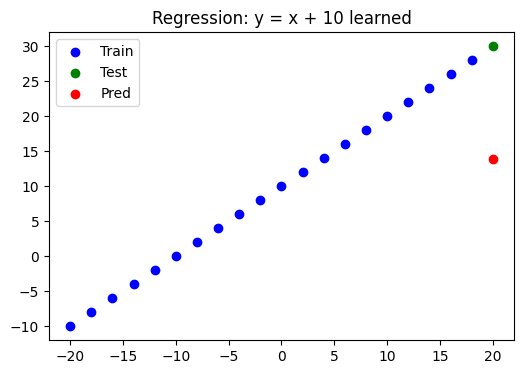

In [20]:
# Predict and visualize
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test,  y_test,  c='g', label='Test')
plt.scatter(X_test,  y_pred,  c='r', label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()

HOMEWORK: Fix the regression model

<h1>Classification</h1>

Test accuracy: 1.000


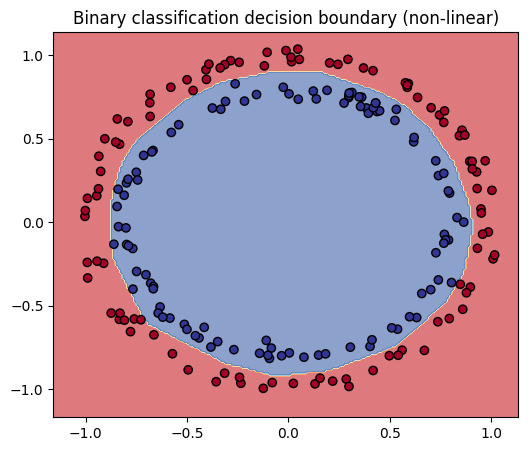

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()


Test accuracy: 0.8848999738693237
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


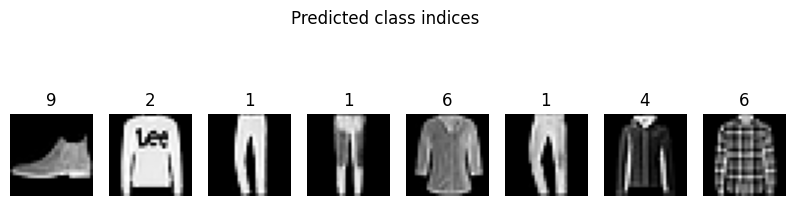

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0

# 1) CREATE (flatten → Dense ReLU → Dense softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask  = np.isin(y_test,  [7, 9])

x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9 else 0
x_test  = x_test[test_mask][..., None]/255.0
y_test  = (y_test[test_mask] == 9).astype(np.float32)

# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)


Test accuracy: 0.9714999794960022


In [24]:

import tensorflow as tf
from keras import layers, models

# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test  = (y_test  < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

# --- Very small CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), # filter size 3*3
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)


Epoch 1/5


C:\Users\rolan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7321 - loss: 0.6393 - val_accuracy: 0.8440 - val_loss: 0.4199
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8357 - loss: 0.4156 - val_accuracy: 0.8667 - val_loss: 0.3703
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8678 - loss: 0.3379 - val_accuracy: 0.8907 - val_loss: 0.2985
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8873 - loss: 0.2932 - val_accuracy: 0.9027 - val_loss: 0.2762
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9024 - loss: 0.2569 - val_accuracy: 0.9047 - val_loss: 0.2782
Test accuracy (tiny CNN): 0.8843333125114441


Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


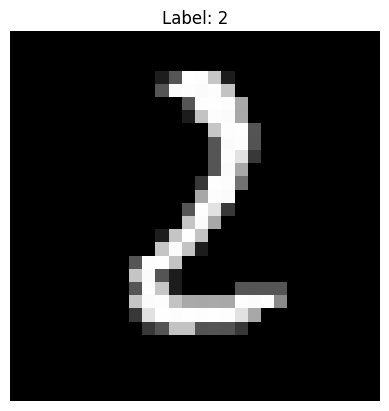

C:\Users\rolan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9063 - loss: 0.3320 - val_accuracy: 0.9501 - val_loss: 0.1780
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9546 - loss: 0.1554 - val_accuracy: 0.9583 - val_loss: 0.1391
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9681 - loss: 0.1101 - val_accuracy: 0.9653 - val_loss: 0.1186
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9752 - loss: 0.0859 - val_accuracy: 0.9643 - val_loss: 0.1152
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9810 - loss: 0.0670 - val_accuracy: 0.9688 - val_loss: 0.0958


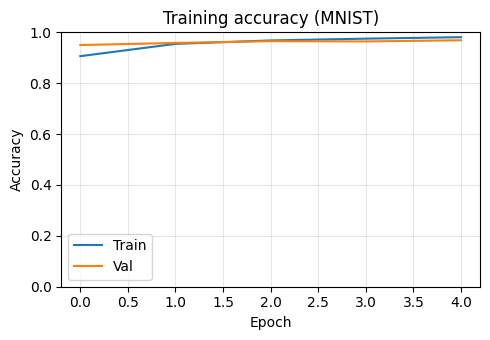

Test accuracy: 0.973
You must install pydot (`pip install pydot`) for `plot_model` to work.


NameError: name 'Image' is not defined

In [25]:
import keras
from keras.datasets import mnist
from keras.utils import plot_model

# --- Load MNIST ---
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# --- Show ONE random image ---
def show_one_example(X, y):
    i = np.random.randint(len(X))
    plt.imshow(X[i], cmap="gray", vmin=0, vmax=1)
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
    plt.show()

show_one_example(x_train, y_train)

# --- Model ---
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# --- Accuracy plot ---
plt.figure(figsize=(5, 3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (MNIST)")
plt.tight_layout()
plt.show()

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# --- Model diagram ---
plot_model(
    model,
    to_file="model_mnist.png"
)

display(Image("model_mnist.png"))

Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


Model: "parallel_mlp_mnist"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 28, 28)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 64)        │     50,240 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 64)        │     50,240 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 128)       │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10)        │      1,290 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9064 - loss: 0.3301 - val_accuracy: 0.9522 - val_loss: 0.1751
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9555 - loss: 0.1524 - val_accuracy: 0.9613 - val_loss: 0.1326
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9685 - loss: 0.1068 - val_accuracy: 0.9653 - val_loss: 0.1162
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9769 - loss: 0.0805 - val_accuracy: 0.9680 - val_loss: 0.1063
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9821 - loss: 0.0626 - val_accuracy: 0.9695 - val_loss: 0.1003


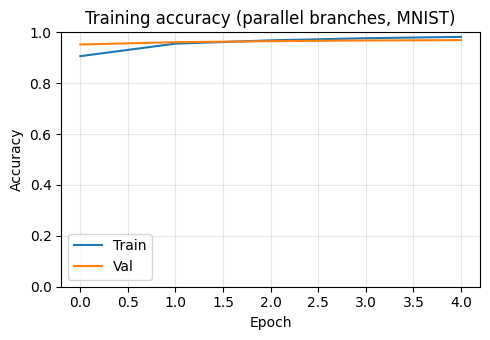

Test accuracy: 0.971


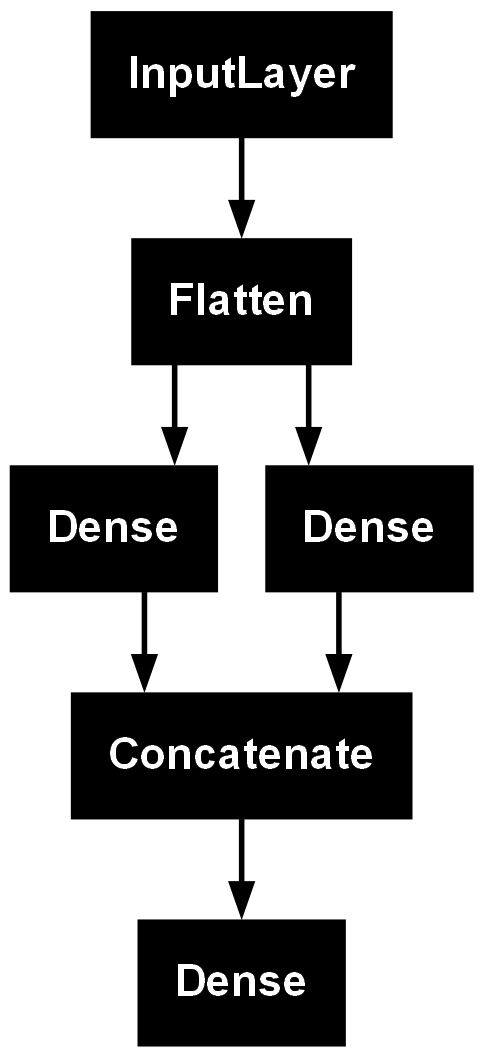

In [ ]:

# --- Load & prep MNIST ---
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)   # (60000, 28, 28), (60000,)
print("Test: ", x_test.shape,  y_test.shape)    # (10000, 28, 28), (10000,)

# --- Parallel-branches MLP (Functional API) ---
inputs = keras.Input(shape=(28, 28), name="input")
x = layers.Flatten(name="flatten")(inputs)                # (None, 784)

# Branch A
branch_a = layers.Dense(64, activation="relu", name="branchA_dense")(x)

# Branch B
branch_b = layers.Dense(64, activation="relu", name="branchB_dense")(x)

# Merge
merged = layers.Concatenate(name="concat")([branch_a, branch_b])

# Output: 10 classes for MNIST digits 0..9
outputs = layers.Dense(10, activation="softmax", name="output")(merged)

model = keras.Model(inputs, outputs, name="parallel_mlp_mnist")

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# --- Plot accuracy ---
plt.figure(figsize=(5, 3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (parallel branches, MNIST)")
plt.tight_layout()
plt.show()

# --- Evaluate on test set ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# --- Model diagram ---
plot_model(
    model,
    to_file="parallel_mlp.png"
)

display(Image("parallel_mlp.png"))

In [ ]:
import os

# --- Load & prep MNIST ---
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)   # (60000, 28, 28), (60000,)
print("Test: ", x_test.shape,  y_test.shape)    # (10000, 28, 28), (10000,)

# --- MLP model ---
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # flattens 28x28 -> 784
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax") # 10 classes for digits 0..9
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# --- Save to a .keras file ---
save_path = "miras_model.keras"
model.save(save_path)
print("Saved model to:", os.path.abspath(save_path))

Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)
Epoch 1/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9160 - loss: 0.2919 - val_accuracy: 0.9507 - val_loss: 0.1683
Epoch 2/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9612 - loss: 0.1298 - val_accuracy: 0.9609 - val_loss: 0.1295
Epoch 3/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9739 - loss: 0.0890 - val_accuracy: 0.9656 - val_loss: 0.1128
Epoch 4/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9814 - loss: 0.0650 - val_accuracy: 0.9683 - val_loss: 0.1047
Epoch 5/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9869 - loss: 0.0486 - val_accuracy: 0.9698 - val_loss: 0.1025
Epoch 6/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9900 - loss: 0.0370 - val_accuracy: 0.9728 - val_loss: 0.0966
Test accuracy: 0.972
Saved model to: c:\Users\z099094\Desktop\2026_kevät_Implementing_IoT_Pipeline\ML\miras_model.keras


In [ ]:
# --- Load & prep MNIST (same dataset as your training cell) ---
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_test = x_test.astype("float32") / 255.0  # test set is enough for evaluation

print("Test:", x_test.shape, y_test.shape)  # (10000, 28, 28), (10000,)

# --- Load the saved .keras model ---
loaded_model = keras.saving.load_model("miras_model.keras")
loaded_model.summary()

# --- Evaluate the loaded model on MNIST test ---
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model - test accuracy: {acc:.3f}")

# --- Predict a few samples ---
probs = loaded_model.predict(x_test[:5], verbose=0)  # shape: (5, 10) for MNIST
preds = probs.argmax(axis=1)

print("Predictions:", preds.tolist())
print("True labels:", y_test[:5].tolist())

Test: (10000, 28, 28) (10000,)


Model: "sequential_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_44 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

Loaded model - test accuracy: 0.972
Predictions: [7, 2, 1, 0, 4]
True labels: [7, 2, 1, 0, 4]
